# 🎯 K-Means Clustering - Complete Learning Guide

## Overview
K-Means is one of the most popular unsupervised learning algorithms for clustering. It partitions data into k clusters by minimizing within-cluster variance. It's simple, fast, and works well for many real-world applications.

## Key Topics Covered:
1. **Clustering Basics** - Unsupervised learning fundamentals
2. **K-Means Algorithm** - Centroid-based clustering
3. **Elbow Method** - Finding optimal k
4. **Silhouette Score** - Evaluating cluster quality
5. **Initialization Methods** - k-means++ vs random
6. **Distance Metrics** - Euclidean and other distances
7. **Real-world Applications** - Customer segmentation, image compression
8. **Advantages & Disadvantages** - When to use

---

## References:
- [K-Means Clustering - Wikipedia](https://en.wikipedia.org/wiki/K-means_clustering)
- [scikit-learn KMeans](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- [K-Means Tutorial](https://www.youtube.com/watch?v=4b5d3muVQWA)

## 📚 Section 1: Import Libraries

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🎯 Section 2: K-Means Basics


🎯 EXAMPLE 1: Basic K-Means Clustering

✅ K-Means Results:
  Number of clusters: 3
  Inertia (Sum of squared distances): 362.7901
  Centroids shape: (3, 2)
  Cluster sizes: [100 100 100]

✅ K-Means Results:
  Number of clusters: 3
  Inertia (Sum of squared distances): 362.7901
  Centroids shape: (3, 2)
  Cluster sizes: [100 100 100]


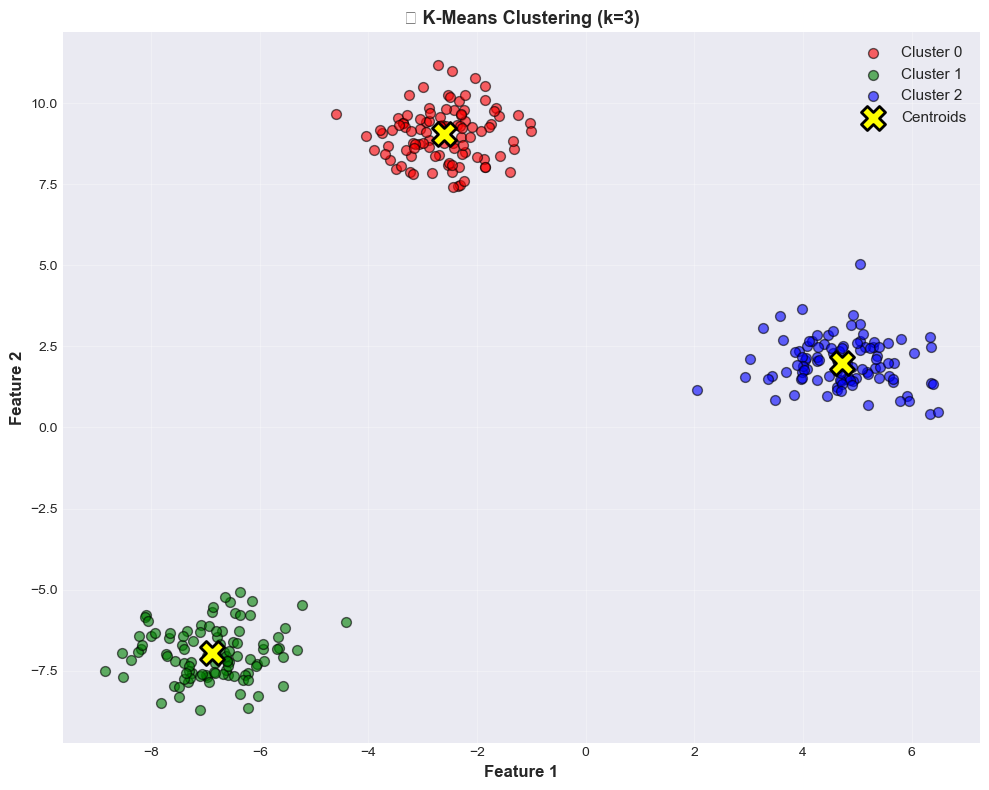

In [2]:
# Example 1: Basic K-Means
print("\n" + "="*70)
print("🎯 EXAMPLE 1: Basic K-Means Clustering")
print("="*70)

# Create synthetic data
X, y_true = make_blobs(n_samples=300, centers=3, n_features=2, 
                        cluster_std=0.8, random_state=42)

# K-Means clustering
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
inertia = kmeans.inertia_

print(f"\n✅ K-Means Results:")
print(f"  Number of clusters: 3")
print(f"  Inertia (Sum of squared distances): {inertia:.4f}")
print(f"  Centroids shape: {centroids.shape}")
print(f"  Cluster sizes: {np.bincount(labels)}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Plot clusters
colors = ['red', 'green', 'blue']
for i in range(3):
    mask = labels == i
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=f'Cluster {i}',
              s=50, alpha=0.6, edgecolors='k')

# Plot centroids
ax.scatter(centroids[:, 0], centroids[:, 1], c='yellow', marker='X', 
          s=300, edgecolors='black', linewidth=2, label='Centroids')

ax.set_xlabel('Feature 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature 2', fontsize=12, fontweight='bold')
ax.set_title('🎯 K-Means Clustering (k=3)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Section 3: Elbow Method & Silhouette Score


📊 EXAMPLE 2: Elbow Method & Silhouette Score

🔍 Testing k values from 1 to 10:
  k= 1: Inertia=20120.54, Silhouette=N/A
  k= 2: Inertia=5526.51, Silhouette=0.7206
  k= 3: Inertia=362.79, Silhouette=0.8781
  k= 3: Inertia=362.79, Silhouette=0.8781
  k= 4: Inertia=318.07, Silhouette=0.6974
  k= 4: Inertia=318.07, Silhouette=0.6974
  k= 5: Inertia=273.36, Silhouette=0.5026
  k= 5: Inertia=273.36, Silhouette=0.5026
  k= 6: Inertia=233.60, Silhouette=0.3268
  k= 6: Inertia=233.60, Silhouette=0.3268
  k= 7: Inertia=200.97, Silhouette=0.3508
  k= 7: Inertia=200.97, Silhouette=0.3508
  k= 8: Inertia=172.85, Silhouette=0.3666
  k= 8: Inertia=172.85, Silhouette=0.3666
  k= 9: Inertia=149.96, Silhouette=0.3686
  k= 9: Inertia=149.96, Silhouette=0.3686
  k=10: Inertia=139.27, Silhouette=0.3568
  k=10: Inertia=139.27, Silhouette=0.3568


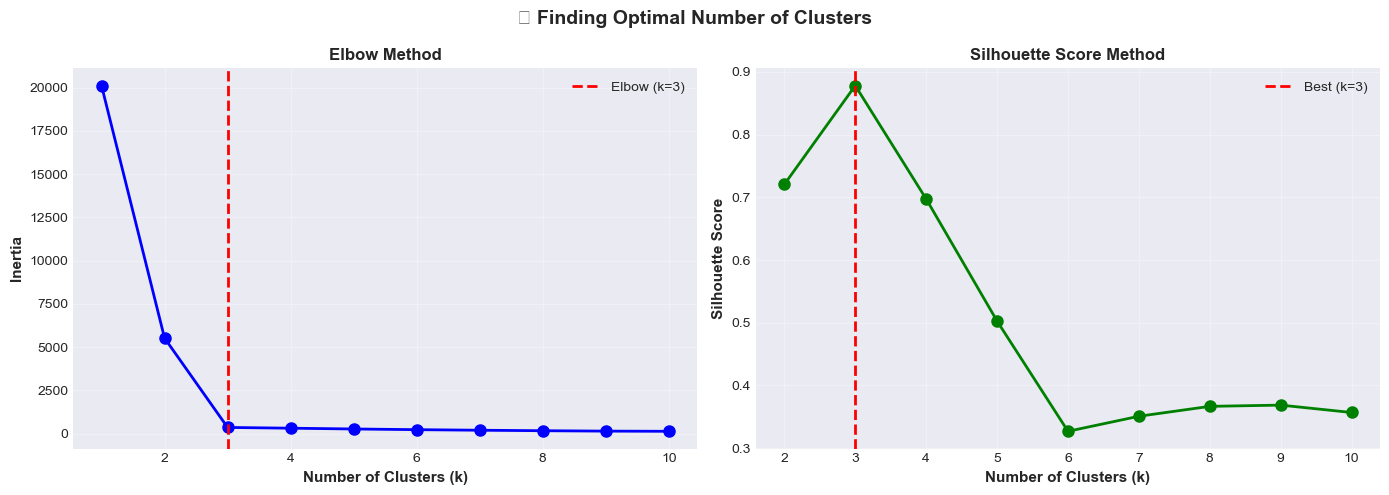


✅ Recommendations:
  Elbow method suggests: k=3
  Silhouette score suggests: k=3


In [3]:
# Example 2: Finding Optimal k
print("\n" + "="*70)
print("📊 EXAMPLE 2: Elbow Method & Silhouette Score")
print("="*70)

# Test different values of k
k_range = range(1, 11)
inertias = []
silhouette_scores = []

print(f"\n🔍 Testing k values from 1 to 10:")
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_temp = kmeans_temp.fit_predict(X)
    
    inertias.append(kmeans_temp.inertia_)
    
    if k > 1:
        sil_score = silhouette_score(X, labels_temp)
        silhouette_scores.append(sil_score)
        print(f"  k={k:2d}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={sil_score:.4f}")
    else:
        silhouette_scores.append(None)
        print(f"  k={k:2d}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette=N/A")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Finding Optimal Number of Clusters', fontsize=14, fontweight='bold')

# Elbow method
ax = axes[0]
ax.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=3, color='r', linestyle='--', linewidth=2, label='Elbow (k=3)')
ax.set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Inertia', fontsize=11, fontweight='bold')
ax.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Silhouette score
ax = axes[1]
sil_k_values = [k for k, s in zip(k_range, silhouette_scores) if s is not None]
sil_values = [s for s in silhouette_scores if s is not None]
ax.plot(sil_k_values, sil_values, 'go-', linewidth=2, markersize=8)
best_k = sil_k_values[np.argmax(sil_values)]
ax.axvline(x=best_k, color='r', linestyle='--', linewidth=2, label=f'Best (k={best_k})')
ax.set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
ax.set_title('Silhouette Score Method', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Recommendations:")
print(f"  Elbow method suggests: k=3")
print(f"  Silhouette score suggests: k={best_k}")

## 🔄 Section 4: Initialization Methods


🔄 EXAMPLE 3: Impact of Initialization

📊 Comparing initialization methods:
  k-means++   : Mean=362.79, Std=0.00
  random      : Mean=1898.65, Std=2346.07


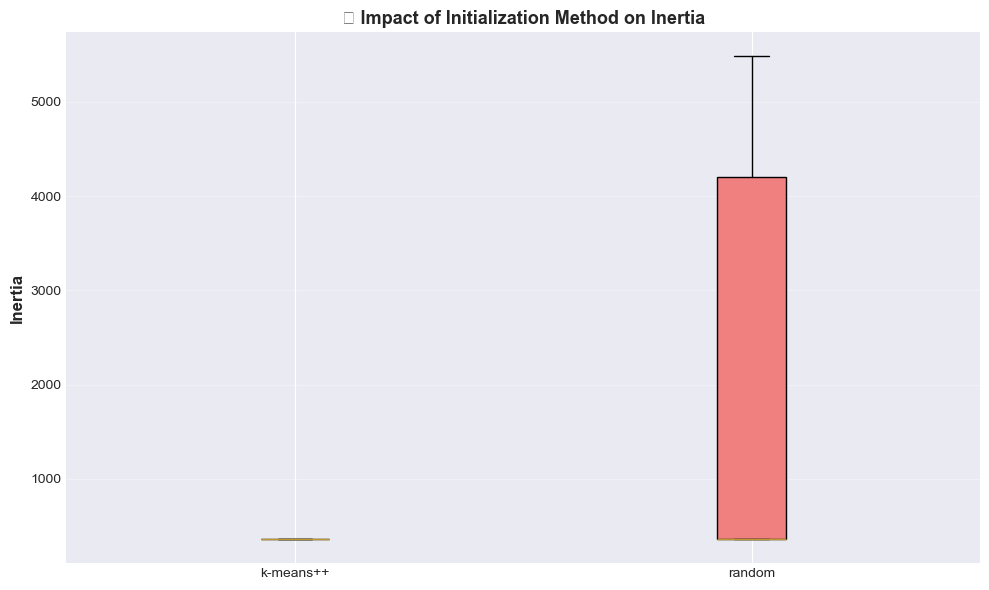


✅ k-means++ provides more stable results (lower variance)


In [4]:
# Example 3: Initialization Impact
print("\n" + "="*70)
print("🔄 EXAMPLE 3: Impact of Initialization")
print("="*70)

init_methods = ['k-means++', 'random']
results = {}

print(f"\n📊 Comparing initialization methods:")
for init_method in init_methods:
    inertias_method = []
    for _ in range(10):
        kmeans_temp = KMeans(n_clusters=3, init=init_method, n_init=1, random_state=None)
        kmeans_temp.fit(X)
        inertias_method.append(kmeans_temp.inertia_)
    
    results[init_method] = inertias_method
    print(f"  {init_method:12s}: Mean={np.mean(inertias_method):.2f}, "
          f"Std={np.std(inertias_method):.2f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot([results['k-means++'], results['random']], 
                 labels=['k-means++', 'random'],
                 patch_artist=True)

colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Inertia', fontsize=12, fontweight='bold')
ax.set_title('🔄 Impact of Initialization Method on Inertia', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✅ k-means++ provides more stable results (lower variance)")

## 🎨 Section 5: Silhouette Analysis


🎨 EXAMPLE 4: Silhouette Analysis


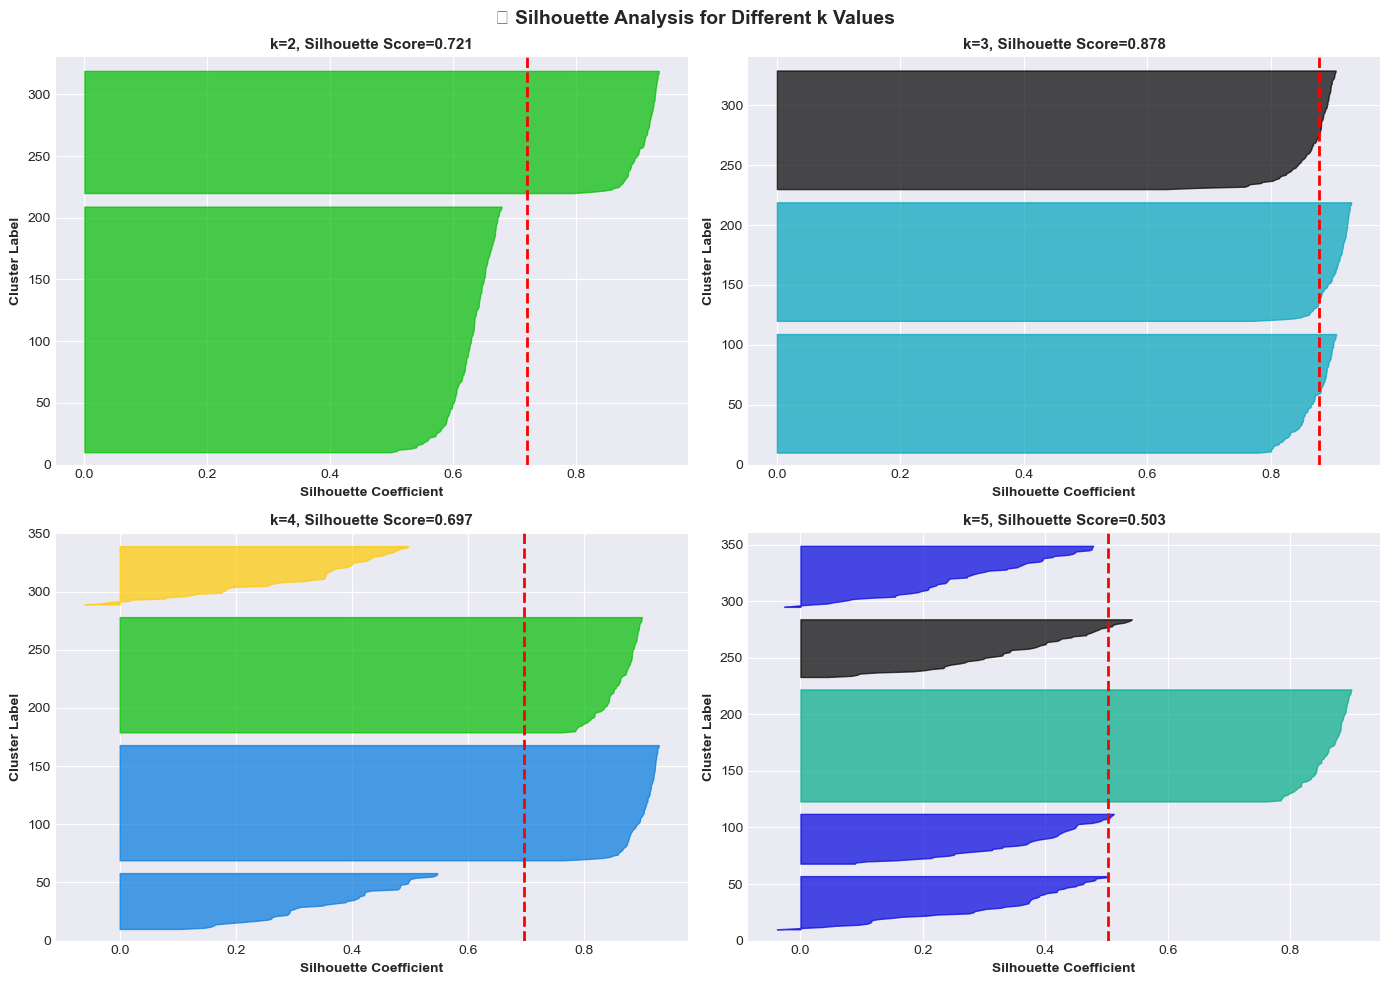


✅ Silhouette Analysis Interpretation:
  - Score close to +1: Good clustering
  - Score close to 0: Overlapping clusters
  - Score close to -1: Wrong cluster assignment


In [5]:
# Example 4: Silhouette Analysis
print("\n" + "="*70)
print("🎨 EXAMPLE 4: Silhouette Analysis")
print("="*70)

k_values = [2, 3, 4, 5]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🎨 Silhouette Analysis for Different k Values', fontsize=14, fontweight='bold')

for idx, k in enumerate(k_values):
    ax = axes[idx // 2, idx % 2]
    
    kmeans_k = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_k = kmeans_k.fit_predict(X)
    
    silhouette_vals = silhouette_samples(X, labels_k)
    silhouette_avg = silhouette_score(X, labels_k)
    
    y_lower = 10
    colors_sil = plt.cm.nipy_spectral(labels_k.astype(float) / k)
    
    for i in range(k):
        cluster_silhouette_vals = silhouette_vals[labels_k == i]
        cluster_silhouette_vals.sort()
        
        size_cluster_i = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i
        
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                         facecolor=colors_sil[i], edgecolor=colors_sil[i], alpha=0.7)
        
        y_lower = y_upper + 10
    
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2)
    ax.set_xlabel('Silhouette Coefficient', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cluster Label', fontsize=10, fontweight='bold')
    ax.set_title(f'k={k}, Silhouette Score={silhouette_avg:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylim([0, len(X) + (k + 1) * 10])

plt.tight_layout()
plt.show()

print(f"\n✅ Silhouette Analysis Interpretation:")
print(f"  - Score close to +1: Good clustering")
print(f"  - Score close to 0: Overlapping clusters")
print(f"  - Score close to -1: Wrong cluster assignment")

## 📊 Section 6: K-Means on Real Dataset


📊 EXAMPLE 5: K-Means on Iris Dataset

✅ K-Means on Iris Dataset:
  Silhouette Score: 0.4389
  Inertia: 102.62


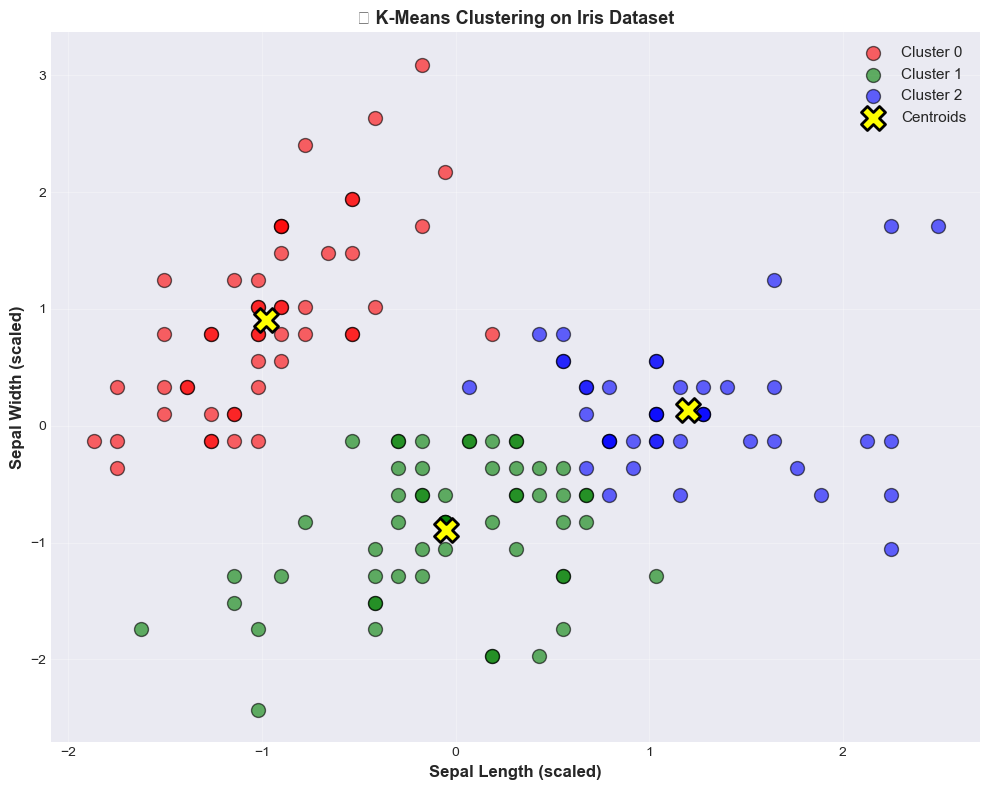

In [6]:
# Example 5: K-Means on Iris Dataset
print("\n" + "="*70)
print("📊 EXAMPLE 5: K-Means on Iris Dataset")
print("="*70)

# Load Iris
iris = load_iris()
X_iris = iris.data[:, :2]  # Use first 2 features for visualization

# Scale data
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Apply K-Means
kmeans_iris = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels_iris = kmeans_iris.fit_predict(X_iris_scaled)

# Silhouette score
sil_score_iris = silhouette_score(X_iris_scaled, labels_iris)

print(f"\n✅ K-Means on Iris Dataset:")
print(f"  Silhouette Score: {sil_score_iris:.4f}")
print(f"  Inertia: {kmeans_iris.inertia_:.2f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red', 'green', 'blue']
for i in range(3):
    mask = labels_iris == i
    ax.scatter(X_iris_scaled[mask, 0], X_iris_scaled[mask, 1], 
              c=colors[i], label=f'Cluster {i}', s=100, alpha=0.6, edgecolors='k')

centroids_scaled = kmeans_iris.cluster_centers_
ax.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], 
          c='yellow', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')

ax.set_xlabel('Sepal Length (scaled)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sepal Width (scaled)', fontsize=12, fontweight='bold')
ax.set_title('📊 K-Means Clustering on Iris Dataset', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📋 Section 7: K-Means Advantages & Disadvantages

### ✅ Advantages:
1. **Simple and intuitive** - Easy to understand and implement
2. **Fast** - O(nkd) complexity, very scalable
3. **Scalable** - Works with large datasets
4. **Works in any dimension** - Not limited to low dimensions
5. **Guaranteed convergence** - Always converges to local minimum
6. **Easy to implement** - Available in most libraries

### ❌ Disadvantages:
1. **Requires choosing k** - No automatic k selection
2. **Local minima** - Sensitive to initialization
3. **Spherical clusters** - Assumes round cluster shapes
4. **Sensitive to outliers** - Outliers affect centroids
5. **May not work with varying sizes** - Clusters of different sizes problematic
6. **Needs scaling** - Feature scaling important for distance metrics

### When to Use:
- Customer segmentation
- Image compression
- Document clustering
- Quick exploratory analysis
- When you need simple and fast clustering

In [7]:
# Example 6: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "K-Means partitions data into k clusters by minimizing within-cluster variance",
    "Algorithm: Initialize centroids → Assign points → Update centroids → Repeat",
    "Elbow method: Find k where inertia stops decreasing rapidly",
    "Silhouette score: Measure how similar points are to their cluster (−1 to +1)",
    "k-means++ initialization: Smarter centroid placement for better results",
    "Always scale features before K-Means (important for distance metrics!)",
    "K-Means assumes spherical clusters of similar size",
    "For non-spherical clusters, consider DBSCAN or hierarchical clustering",
    "Very fast - good for real-time applications",
    "Remember: Need to specify k beforehand (unsupervised challenge!)"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. K-Means partitions data into k clusters by minimizing within-cluster variance

 2. Algorithm: Initialize centroids → Assign points → Update centroids → Repeat

 3. Elbow method: Find k where inertia stops decreasing rapidly

 4. Silhouette score: Measure how similar points are to their cluster (−1 to +1)

 5. k-means++ initialization: Smarter centroid placement for better results

 6. Always scale features before K-Means (important for distance metrics!)

 7. K-Means assumes spherical clusters of similar size

 8. For non-spherical clusters, consider DBSCAN or hierarchical clustering

 9. Very fast - good for real-time applications

10. Remember: Need to specify k beforehand (unsupervised challenge!)

